# MonOCR Preview
Simple demonstration of Mon Language OCR on Images and PDFs.

In [1]:
import io
import os
import torch
from pathlib import Path
from PIL import Image

from pdf2image import convert_from_path
from IPython.display import display, Image as IPyImage, Markdown

from monocr import MonOCR


In [2]:
project_root = Path("..")
img_dir = project_root / "data" / "images"
pdf_dir = project_root / "data" / "pdfs"


In [3]:
_original_torch_load = torch.load

def safe_torch_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _original_torch_load(*args, **kwargs)

torch.load = safe_torch_load


In [4]:
try:
    ocr = MonOCR()
    print("OCR Engine Initialized")
except Exception as e:
    print(f"OCR Initialization Failed: {e}")
finally:
    torch.load = _original_torch_load


OCR Engine Initialized


In [5]:
def display_pil_image(img: Image.Image):
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    display(IPyImage(data=buf.getvalue()))


## Image OCR
Processing all images in `data/images`.

📷 Found 7 images



## 000028.jpg

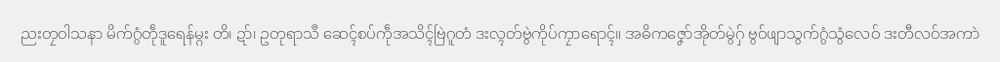

**OCR Result:**

```
ညးတၠဝါသနာမိက်ဂွံတဵုဒူရေန်မ္ဂးတိ၊ဍာ်၊ဥတုရာသဳဆေၚ်စပ်ကဵုအသိၚ်ဗြဲဂုတံအးလ္ၚတ်ဗွဲကိုပ်ကၠာရောၚ်၊အမိကဇၞော်အိုတ်မွဲဂှ်ဗွဝ်ဖျာသွက်ဂွံသွံလေဝ်အးတဳလဝ်အကာဲ
```

------------------------------------------------------------


## 000029.jpg

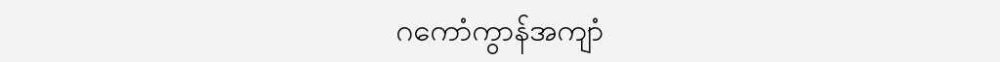

**OCR Result:**

```
ဂကောံကွာန်အကျာံ
```

------------------------------------------------------------


## pdf_screenshot.png

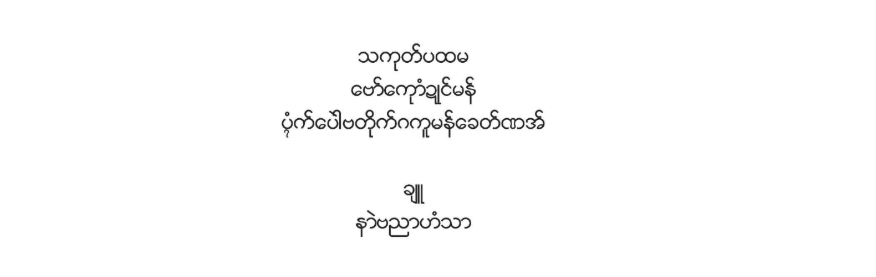

**OCR Result:**

```
ဗော်ကေုာံဍုင်မန်
ပ္ၚံက်ပေါဗတိုက်ဂကူမန်ခေတ်ဏအ်
ျ
ှ်ါြါါပါါ်)
```

------------------------------------------------------------


## test_0005_h71.png

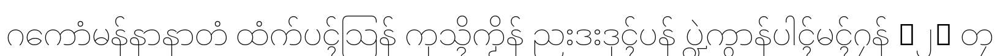

**OCR Result:**

```
ဂကောံမန်နာနာတံထံက်ပၚ်သြန်ကုသ္ိကၟိန်ညးဒးဒုၚ်ပန်ပ္ဍဲကွာန်ပါၚ်မၚ်ဂၠန်(၂)တၠ
```

------------------------------------------------------------


## test_0006_h61.png

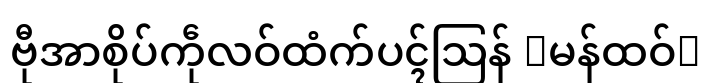

**OCR Result:**

```
ဗီုအာစိုပ်ကဵုလဝ်ထံက်ပၚ်သြန်(မန်ထဝ်)
```

------------------------------------------------------------


## test_0011_h30.png

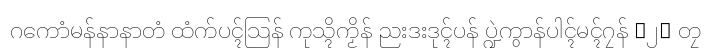

**OCR Result:**

```
ဂကောံမန်နာနာတံထံက်ပၚ်သြန်ကုသ္ၚိကၟိန်ညးဒးဒုၚ်ပန်ပ္ဍဲကွာန်ပါၚ်မၚ်ဂၠန်(၂)တၠ
```

------------------------------------------------------------


## test_0012_h86.png

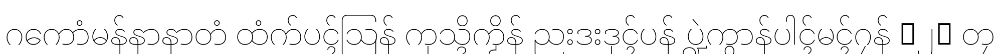

**OCR Result:**

```
ဂကာံှ်စှာစှ်ာာံထံဂက်ပ္ၚ်သြစှ်ကုသ္ၚိကၠိစှ်ညးံဒးဒှုပၚ်ပစှ်ပ္ဍဲကွာှ်ပါပ္ၚ်ဖပ္ၚ်ဂစှ်၂)ၠှ
```

------------------------------------------------------------


In [6]:
if not img_dir.exists():
    print("Image directory not found")
else:
    images = sorted(
        list(img_dir.glob("*.png")) +
        list(img_dir.glob("*.jpg")) +
        list(img_dir.glob("*.jpeg"))
    )

    print(f"📷 Found {len(images)} images\n")

    for img_path in images:
        display(Markdown(f"## {img_path.name}"))

        # OCR
        text = ocr.read_text(img_path)

        # Display image
        display(IPyImage(filename=str(img_path)))

        # Display OCR result
        display(Markdown("**OCR Result:**"))
        display(Markdown(f"```\n{text}\n```"))

        print("-" * 60)


## PDF OCR
Processing all PDFs in `data/pdfs`.

Found 1 PDFs



# party_mission.pdf

## Page 1

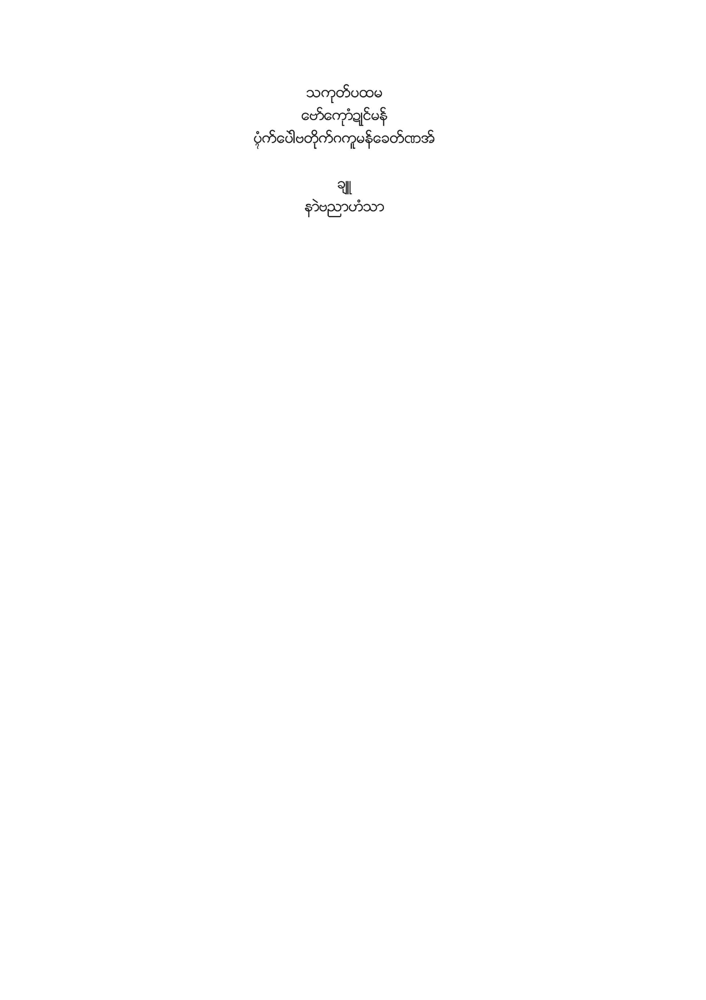

**OCR Result:**

```
ဗာ်ွကုာံြပ်မရှ်
္ၚံက်ပါပဗြတိုက်ဂကုမန်ပါတ်ဏအ်
ျ
ှ်ါပါါါါါ)
```

----------------------------------------


## Page 2

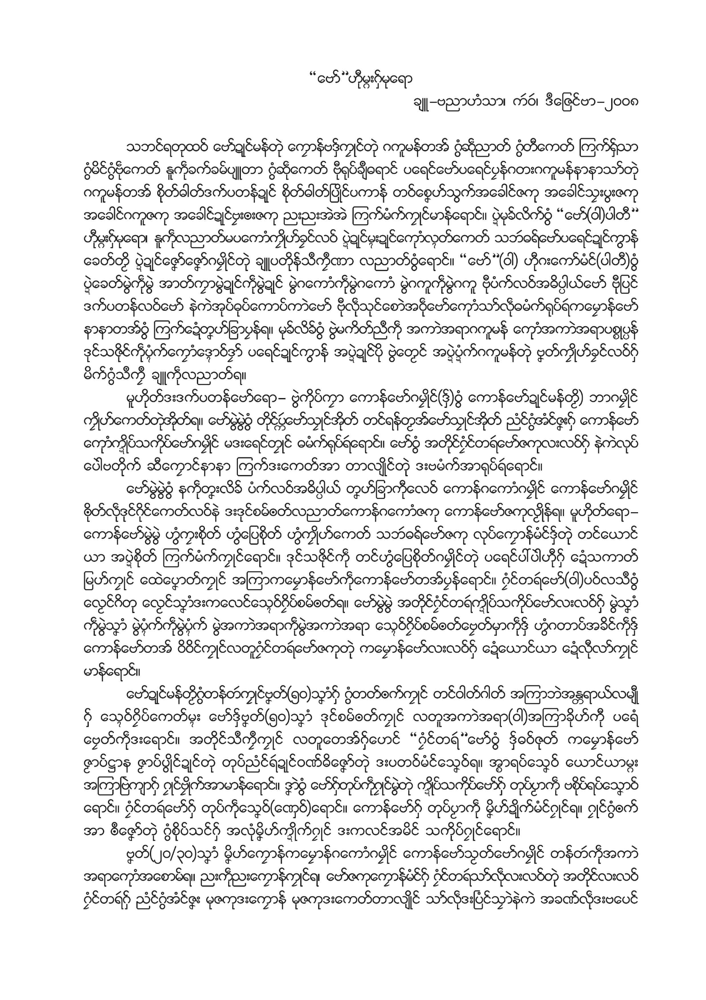

**OCR Result:**

```
(ဗာ်ဟိုွဂးဂှ်မုရ်ာ
ချာဟာံာါဒဳိြင်ာ၂
သာာင်ရ်ုာ်ဗာ်ဍပ်ပန်တုဲၠောန်ဗှ်ၠု်တုဲဂုမန်တအ်ဂွံိုာာ်ဂွံာိကာ်ဂြ်ှ်ာ
ဂွိင်ဂွံဵုကာ်ဒုံကဵုက်ခါပ်ျာဂွံဵုကာ်ပိုုပ်ျိဳပရာ်ရ််ြာ်ရ်ပ်ၠန်ဂားဂုမန်ှ်ာနှ်ာ်ုဲ
ဂုပန်တအ်စို်ပါတ်ပိက်ာန်င်စို်ပါတ်ပြိုင်ပန််ၞဟ်ွ်ပါ်ြုခါင်သၠးပွးဇြိဂု
အပပေါင်ဂကူြိဂုပပါပ်ဍပ်ၠးဂးဂြိဂကုညးညြးအဲအဲဂြ်မံက်ၠုပ်မာန်မရာပ်ပ္ဍဲု်လိက်ွံမဗပာ်ါပါတိ
ဟို္ဂဂှ်ုြရ်ဒှုံကဵုာာ်မပကောံၠိုဟ်ၠိၚ်လ်ပ္ဍဲဍပ်မ္ၚးဍပ်ြဂကုာံ္ၚာ်ကာ်သာ်ရ်ပဗာ်ြရ်ပ်ဍုပ်ကွာန်
ခါတ်တၟိပ္ဍဲဍပ်ဇၞော်ဇၞော်ဂမၠိုၚ်တုဲချူပတိုနှ်သဳကၠိဏာလာတ်ွံမရာပ်ူ(ဗာ်ါဟိုဂးမြဂကော်မံပၚ်ပါတိဂွံ
ပ္ဍဲပါတ်မွဲကဵုမွဲာာ်ၠာမွဲဍုပ်ကဵုမွဲဍင်မွဲဂမကာံကဵမွဲဂမကာံမွဲဂကုကဵုွဲဂကုပိုပံက်လဝ်အမိပါယ်မဗာ်ပိီုပြင်
ိက်န််ာ်နဲဲုပ်ုပ်ာ်ာဗာ်ပီုလုု်ာုာ်ာံ်ုပမံ်ရုပ်ရံမၠာန်ာ်
နှာနှ်ာ်ွံဂြ်ဍံၞဟ်မြာၠန်ရမု်ဂိ်ွံပွဲပကိတ်ဳကဵု္ဂာရာုပနှ်ဂုာံဂာရ်ာပွိပနှ်
ဒိုင်သိုင်ကု္ၚံက်မဂၠောံမ္ၚော်ၠာ်ပရ်ပ်ဍုပ်ကွာနှ်ပ္ဍဲဍပပိုပွဲမတၟင်အပ္ဲ္ၚံက်ဂဂုမန်တုဲပၞတ်ၠိုဟ်ၠၚ်လ်ှ်
မိက်ဂွံသဳိကၠဳချူကဵုလာာ်ရ။
မုဟိုတ်ဒိးပိက်ပန်မဗာ်ရပွဲိုပ်ၠာာန်မဗာ်ဂမၠိုပ်ဒှ်ဝွံကာန်မဗာ်ဍပ်မနှ်တၟိဘာဂမၠိုင်
ၠိုဟ်မြက်တုဲို်ရမဗာ်ွွံတို္တဗာ်ၠုပ်အို််ရန်တၟအ်ပဗာ်ၠုပ်အို်ညြံ်ဂွံံပ်္ၞဂှ်မိဂာနှ်မဗာ်
ကုာံ္ိုပ်ကို်ြဗာ်မၠို်မဲိးဂရ််တၠိုင်မံက်ရုပ်ရရာဗာွံအတို်ဂၠိ်ရာ်ုးဂှ်နဲု်
ပါဲဗြတိုက်ဆိြၠောင်စှာနှ်ာဂြက်ပဂိးကာ်ာာလျိင်တုဲပဒိးဗြမံက်္ာရိုပ်ရဴပ်ရ်ာင်ူ
ဗာ်ွဲွွံနှံကဵုတၞးဂိ်ပံက်လ်ိပါပယ်ၞဟ်မြာကီုလ်ကာန်ဂကာံဂမၠိုင်ကာန်ပဗာ်ဂမၠိုင်
ဇိုတ်လဵုုပ်ို်က်လ်နှ်ဒိးဒိုင်််ာ်ာန်ာံုန်ာ်ုိ်ရမုဟို်ရ
ကာန်မဴဗာ်မွွဲဟွံၠးို်ဟွံ်ပြိုတ်ဟွံၠိုဟ်ွကာ်သာဴပရ်ပြဗာ်ြိဂုလုပ်ၠာန်မံပ်ဒှ်တုဲ်ြယာင်
ာအပ္ၚဲိုတ်ကြက်မံက်ၠုၚ်မရ်ာပ်ူဒိုပ်သိုၚ်ကဵုင်ဟွံပ်ပြိုတ်ဂမၠိုပ်တုဲပမရ်ပ်ပါပါဟိုှ်ပဍံညဂာတာ်
မြံဟ်ၠုင်ဲပၞောာ်ၠုၚ်္ဂြာမမၠာန်မြဗာ်ကဵုွကာန်မြဗာ်ာအ်ပၠန်ပဴရ်ာ်ူဂၠံၚ်ရဗာ်ါပ်ွံ
ၟင်ိတုလၟေင်သၞာံိးကမလေင်ဴသ္ၚ်ၠိပ်ပမ်ဂိတ်ရဗာ်ွဲွဲတို်ဂၠံၚ်တရ္ဍိုပ်ကို်ဗာ်လးဂ်ှ်မွဲၞာံ
ကဵွဲၞာံမွဲပၚံ်ကဵွဲ္ၚံက်မွဲာဵွဲာၚၠိ််ၠ်မှာှ်ဟွံာ်ိင်ကှ်
ကာန်ပဗာ်ာအ်ိိ်ၠုင်လြံ်ာ်ြုုဲမၠာန်ဗာ်းလ်ှ်ံာ်ာံု်ၠုင်
မာန်ပြရ်ာါ
ဗာ်ဍပ်မနှ်တၟိွံာနှ်ၠုပ်ဗၞတ်သၞာံှ်ဂွံာာ်ဂိက်ၠုၚ်င်ါတ်ါတ်ြာာဲ္တရယ်မျိ
ဂှ်သ္ၚ်ၠိပ်က်မ္ၚးဗာ်ဒှ်ဗၞတ်ဴါသၞာံဒိုင်ဂမ်ဂဴတ်ၠုၚ်တုဂာဲတရ်ာါ္အဂြာခိုဟ်ကီုရံ
ဗၠေတ်ကဵုပိးဂဴရာင်။္တိုင်သဳကၠိဳဂၠု်တု၆ြာအ်ဂှ်ွဟင်ဂၠံၚ်ရြဗာ်ွံဒှ်ပပ်ု်ကမၠာန်မဴဗာ်
ဇၟာပ်ြာစှ်ဇၟာပ်ပွို်ဍုပင်တုဲုပ်ညြံပ်ရဴဍုင််ိဇၞော်တုဲ်မံ်မသၞပ်ရွာရပ်သၞ််ယာမ္ဂး
အြာပြဴျာှ်ဂၠှိပၠို်ာမာနှ်ြရ်ၞာွံဗာ်ှ်ု်ှပ်ွဲုဲက္ဍိုပ်ကို်ဗာှ်ုွာုံဗရို်ရပ်သၞာ်
ရာင်ူဂၠံၚ်ရမဗာ်ှ်ုပ်ကဵုသၞေ်ှ်ရာ်ာန်မဗာ်ှ်ုပ်ပွာကဵုမၞိဟ်ဍိက်မံၚ်ဂၠုပ်ရ။ဂၠိုပ်ဂွံဂိက်
အာၜဳဇၞော်တုဲဂွံိုပ်သၚ်ဂှ်လုံမၞိဟ်က္ဍိုက်ဂၠု်ပဂိးကလင်အတမိင်သကိုပ်ဂၠိုင်မရာင်ူ
ပၞတ်၂သၞာံမၞိဟ်ၠောန်ကမၠာနှ်ဂကာံဂမၠိုၚ်ဂာန်ဇဳဗာ်သၟိတ်ြဗာ်ဂမၠိုၚ်န်ဝဲကဵုဒဂာဲ
္ရ်ြကုာံာ်ရညြးကုးဂၠာန်ၠုပ်ရါဗာ်ြိကုြဂၠာန်မံ်ှ်ဂၠိ်ရ်ာ်ုးလ်ုဲို်လးဂ်
ဂၠံၚ်ရ်ညံ်ဂွံံၚ်ဇၞးမုြုပးၠောန်မုြုပိးကာ်ာျိုင်သာ်လဵုပပြံ်သၠာန်ကဲပါဏ်လဵုိးဗပေင်
```

----------------------------------------


## Page 3

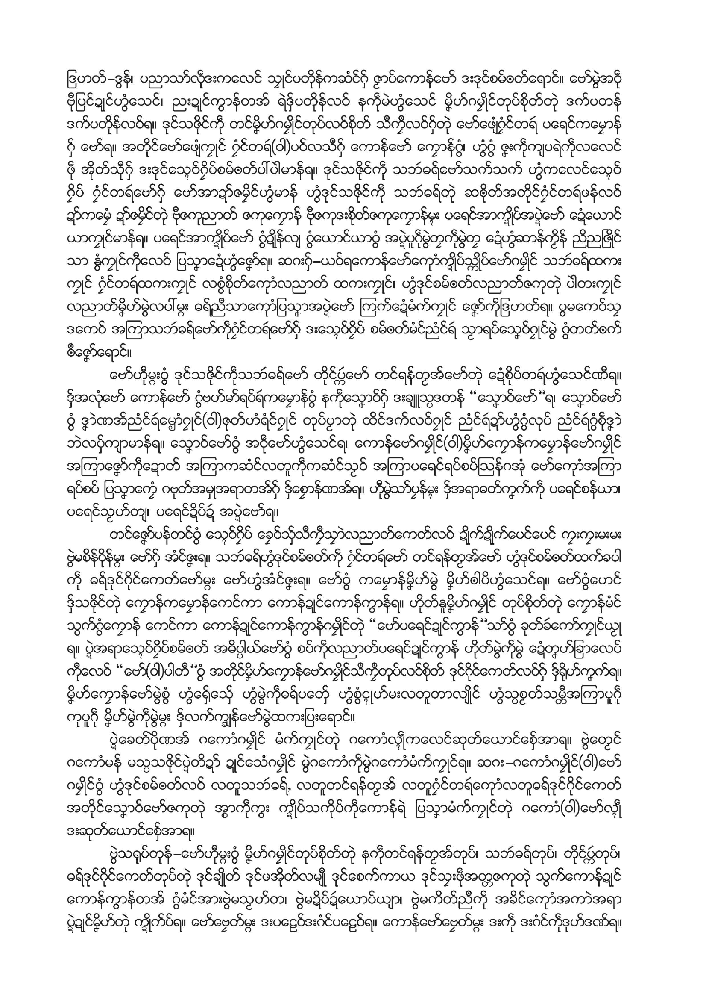

**OCR Result:**

```
ပြိဟတ်ွန်ပာာ်လဵုးလ်သၠုပ်ပိုန်ဍံ်ှ်ဇၟာပ်မာန်မာ်ဒု််မရဗာ်ွဲု
ပီုပြင်ဍပင်ဟွံသဝ်ညြးဍင်ကွာန်တအ်ရဲဒှ်ပတိုန်လ်နှ်ကဵုမဲဟွံသင်မၞိဟ်ဂမၠိုၚ်တုပ်စိုတ်တုဲပိက်န်
ပိက်ိုန်လ်ရဒိုင်သိုင်ကဵု်မၞိဟ်ဂမၠိုင်ု််ို်သၠိ်ှ်ုဲဗာ်ပျံြံ်ဴ်ၠာန်
ဂှ်ဗာ်ရ။တတိုင်ဗာ်ပျြံၠုၚ်ဂၠံၚ်ရပါပ်လဳှ်ကာန်ပဗာ်ၠောန်ဂွံဟွွံဇၞးကဵုကျပရ်ဲကဵုလင်
ပဵုကိုတ်သိုဂှ်ပဂိးဒိုင်သ္ၚေ်ၠိပ်ပမ်ဂဴတ်ပါပါဲမာန်ရဒိုင်သိုင်ကဵုသာဴပရ်မဳဗာ်သက်သက်ဟွံဂလင်သ္ၚဝ်
ဂၠိပ်ဂၠံၚ်ရဴဗာ်ှ်ဗာ်ာဍာ်ဒမၠိၚ်ဟွံမာန်ဟွံဒပိုင်သိုင်ကဵုသာဴပရ်တုဲဓိုတ်္တတိုင်ဂၠံၚ်ရပြန်လ်
ဍာ်မၠံဍာ်မၠိ်တုဲပိုာ်ၠောန်ပိုုးို်ၠောန်မ္ၚးရ်ာ္ိုပ်ပၚဲဗာ်ံယာ်
ာၠိုပ်မာနှ်ရရ်ပ်တာ္ိုပ်ြဗာ်ဂွံဍိန်လျဂွံယာ်ယာွံပ္ၚဍဲာဵုွဲၠကဵုွဲၠဍံဟွံာန်ကၟိနှ်ညြိြြိင်
သာဂွံၠုၚ်ကီုလ်ပြသၞာဍံဟွံဇၞာ်ရါဂးဂှ်ည်ရမကာန်မဗာ်ြဂကုာံက္ဍိုပ်္ိုပ်ြဗာ်ဂမၠိုင်သာဴပရ်း
ၠုၚ်ဂၠံၚ်ရဴးဂၠုင်လွံိုတ်ကာံလာာ်းဂၠုၚ်၊ဟွံိုင်ပပ်ဂဴတ်လာာ်ြိကုုဲပါတးဂၠုင်
ာ်မၞိဟ်မွဲပါမ္ဂးရ်ဳညာကုာံပြသၞာအပ္ၚဲဗာ်ဂြ်ပဍေံမံက်ၠုၚ်ဇၞော်ကဵုပြိဟာ်ရပွမက်သၠေ
ိက်အဂြာာမရ်မဗာ်ကဂၠိ်တရမဗာ်ှ်ပဒိးသၚေ်ၠိ်မ်တ်မံပ်ညြံပ်ရဴသၟာရပ်သၞ်ဂၠုပ်မွဲဂွံ်က်
စဳဂဇၞော်ရာ်ူ
ဗာ်ဟီုမ္ဂးွံဒိုင်သိုၚ်ကဵုညာဴမရ်မဳဗာ်တိုင်ပ္ဴမဗာ်င်ရန်တၟအ်ြဗာ်တုဲံိုပ်ရဴဟွံသၚ်ဏီရ။
ှ်္တလုံဗာ်ကာန်ပြဗာ်ဂွံဟ်ပ်ရပ်ရမၠာန်ွံနံကဵုသၞာ်ှ်ပးျွပိန်ၞာ်ဗာ်သၞာ်ဗာ်
ွံပၞာဲဏအ်ညြံပ်ရဴမ္ွာံဂၠုၚ်ပါဇိုတ်ဟံရံၚ်ဂၠုင်ုပ်ပွာတုဲိင်ပိက်လဝ်ၠုၚ်ညြံပ်ရဴပဍာ်ဟွံဂွံလုပ်ညြံပ်ရဴဂွံဵုဒၞာဲ
ဘဲလပှ်ကျာမာန်ရ။သၞာ်ြဗာ်ွံ္ပဵုြဗာ်ဟွံသ်ရ်ကာန်မြဗာ်ဂမၠိုၚ်ါမၞိဟ်မွၠာန်ဂမၠာန်မြဗာ်ဂမၠိုင်
ဂြာဇၞော်ကဵုပဍောာ်္ဂြာဂဍာံၚ်လတုကဵုကချာံ်သၟပ်္ဂြာပရေ်ပ်ရပ်ပပ်ြန်ဂအုံဗာ်မဂကာံတဂြာ
ပ်ပ်ပြသၞာၠံဂုာ်မှ်ပရ်ာာအ်ှ်ဒှ်ဂှာန်ဏ်ရဟိွဲာ်ၠန်မ္ၚးှ််ၞ်ဵုပ်ပြန်ယာ
(ရ်ပ်သၟိဟ်တျရ်ပ်ဍိပ်ဴပ္ၚဲဳဗာ်ရ
်ဇၞော်ပန််ွံသ္ၚေ်ၠိ်ၠေ်ှၠဳၠာာ်ကာ်လ်ဍိက်ဍိက်ြပေ်ွပ်ဂၠးဂၠးပိပး
ပွဲမိနှ်ိုန်မ္ဂးမဗာ်ှ်အံပ်ဇၞရါသာ်ရ်ဟွံုပ်ပမ်ဂြိတ်ကဵုဂၠိ်တရမဗာ််ရနှ်တၟအ်မြဗာ်ဟွံုပ်ပမ်ိတ််ါါ
ကဵုရ်ဒိုပ်ဂိုင်ဂာ်မြဗာ်မ္ဂးဗာ်ဟွံအံပ်ဇၞးရဗာ်ွံဂမၠာန်မၞိဟ်မွဲမၞိဟ်ဂါပိဟွံပသင်ရ။ဗာ်ွံပဳပဟင်
ှ်ညိုင်တုဲၠောန်မၠာန်မက်ကာကာန်ဍပ်ပကာန်ကွာန်ရဟိုတ်ဒဵုဲမၞိဟ်ဂမၠိုင်ုပ်စိုတ်တုဲၠောန်မံင်
သွ်ွံမၠာန်မကင်ကာကာန်ဍပ်မြကာန်ကွာန်ဂမၠိုၚ်တုဲ(မဗာ်ပမရ်ပ်ဍပ်ကွာနှ်သာ်ွံခိုတ်ါဴမဂာ်ၠုပ်ယၟဲ
ျါပ္ဍဲရ်သ္ၚ်ၠိပ်ပ်တ်ိပါဲယ်ာ်ွံပ်ကဵုလာ်ရပ်ဍပ်ကွာန်ဟိုတ်မွဲကဵုမွဲဍံတၞိဟ်မြာလပ်
ကီုလ်(ဗာ်ပါပါတိဝွံ္တိုၞိဟ်ၠာန်ြဗာ်မၠိုင်သိၠို််ိုာ်ဒိုပ်ို်ြကာ်လ်ှ်ဒှရိုဟ်ၞ်ရ
မၞိဟ်မကၠောန်မဗာ်မွဲွံဟွံပ်ရှ်မသှ်ေဟွံမွဲကဵုမရ်ပမတှ်ဟွံွံ္ၚဟ်မးလတူာလျိုင်ဟွံသ္ပပိတ်သမ္တီအကြာပူဵု
ဂုုဵုမၞိဟ်မွဲကဵုမွဲမ္ဂးဒှ်လက်က္ျဒှ်မဳဗာ်မွဲးပြးရ်ာင်ူ
ပ္ဍဲမပါတ်ပိုဏအ်ဂကာံဂမၠိုၚ်မံက်ၠုၚ်တုဲဂကာံလ္ၚုံကလင်ုတ်ွယောင်စှ်အာရ။ပွဲမတၟင်
ဂကာံမနှ်မသပသိုင်ပ္ၚဲတိဍာ်ဍုင်မသံဂမၠိုၚ်မွဲဂမကာံကဵုမွဲဂမကာံမံက်ၠုပ်ရ။ဂးကာံဂမၠိုၚ်ပါမဗာ်
ဂမၠိုၚ်ဂွံဟွံဒိုင်ဂမ်ဂဴတ်ဂ်တုညဴမရ်တုာ်ရန်တၟအ်ဂတုၠံၚ်ရဴမကုာံလတုမရ်ဒိုပ်ဂိုင်ကာ်
္တိုင်ဴသၞာ်မဗာ်ဂြိကုတုဲတွာကဵုကွးဂက္ဍိုပ်သကိုပ်ကဵုမြဂကာန်ရဲပြသၞာမံက်ၠုၚ်တုဲဂကာံပါမဳဗာ်လ္ၚုံ
ပဂိးုာ်ယာင်ဂှ်ာာရ
ပွဲရိုပ်တု်ာဟို္ဂးွံမၞိဟ်ဂမၠို်ုပ်ိုတ်တုဲံကဵု်ရန်တၟ်ုရ်ုဲို္ုပဲ
ရ်ဒိုပ်ိုင်ကာ်ုပ်ုဲဒိုင်ချိတ်ဒိုပ်ို်ျဒို််ာဒိုင်သၠးပို္တုုဲသွ်ွကာန်ဍင်
ကာနှ်ကွာနှ်တအ်ဂွံမံပ်ားပွဲမသၟိဟ်တပွဲမဍိပ်ဴမယာပ်ယျာပွဲမကိတ်ညြဳကဵုအခိင်မကာံအကာဲအရ်ာ
ပ္ဍဲဍပ်မၞိဟ်တုဲက္ဍိုက််ရဗာ်ဗၠေတ်မ္ဂးပိးပပပ်းဂိ်ပ်ရန်ဗာ်ၠေ်မ္ဂးးကုဂိ်ကုိုဟ်ိ်ရ
```

----------------------------------------


## Page 4

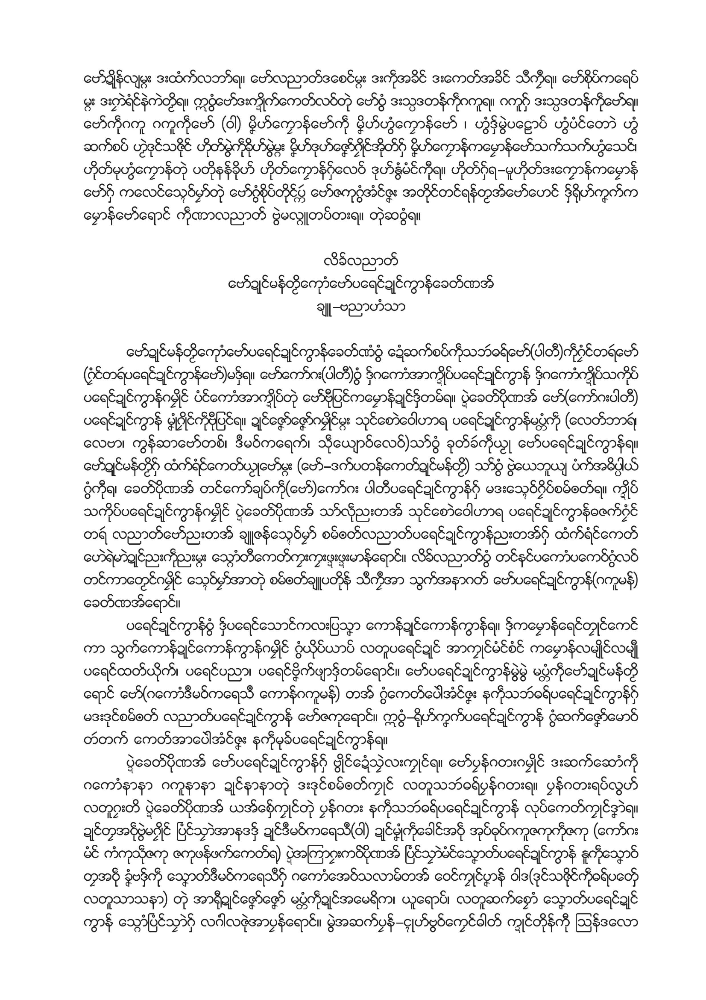

**OCR Result:**

```
ဗာ်ဍိန်လျမ္ဂးပးဏံ်လာာ်ရဗာ်လာ်ဒိပှင်မွးပ္ိးကဵုခိင်ပးကာ်ခိ်သိၠိရဗာ်ို်ရ်ပ်
မ္ဂွပဂးၠှာရိ်န်ကတၟိရက္ွိဗာ်းက္ဍို်ကာ််ုဲဗာ်ွံဒိးသ္ပဒိတနှ်ကုဂူရါဂျှ်ဒိးသွပိတာနှ်ကဵုဗာ်ရ
ဗာ်ကဵုဂဂုဂဂုကဵုွဳဗာ်(ါမၞိဟ်ၠောန်ဗာ်ကဵုမၞိဟ်ဟွံဴၠာန်ဳဗာ်၊ဟွံဒှ်မွဲပပ္ပောပ်ဟွံပံင်ာဲဟွံ
ခ််ဟၟံု်သို်ဟို်ွဲိုိုဟ်ွဲ္ဂးမၞိဟ်ိုဟ်ဇၞော်ၠိုပ်ို်ှ်မၞိဟ်မြၠောန်မၠောန်မဗာ်က်က်ဟွံသဝ်ါ
ဟိုတ်မုဟွံပဂၠာနှ်တုဲိုန်န်ခိုဟ်ဟို်ၠောန်ှ်လ်ဒိုဟ်ဂွံမံ်ကီုရဟို်ှ်ရမုဟို်ဂးၠောန်မၠာန်
ဗာ်ှ်ကလင်သ္ၚေ်မၠာ်တုဲမဗာ်ွိုပ်တို္တဴဗာ်ြိကုွံံပ်ဇၞးအတို််ရနှ်တၟအ်ဗာ်ဟ်ှ်ရိုဟ်ၞ်
မၠာန်ပဳဗာ်ဂရာင်ကဵုဏာလာာ်ပွဲမလ္ဂုပ်တးရ။ုဲဍွံရ
ဂိ်လာာ်
မဗာ်ဍပ်မနှ်တၟိမကေုာံမဗာ်ပမရပ်ဍုပ်ကွာန်မပါတ်ဏအ်
ျါါါါ)
ဗာ်ဍုပ်မန်တၟိမကုာံမဗာ်ပရေ်ပ်ဍုပ်ကွာန်ပပါတ်ဏံွံပဍံဍ်ပပ်ကဵုာဴမရ်မဗပာ်ပါတိကၠိ်တရ်မဗာ်
ဂိ်ရရပ်ပ်ကွာန်ဗာ်မဒှ်ရဗာ်ဂာ်ံပါတွံဒှ်ဂာံာ္ဍိုပ်ရေ်ပ်ဍြင်ကွာန်ဒှ်ဂဂာ္ိုပ်ကို်
ရ်ပ်ဍင်ကွာန်ဂမၠိုင်ံ်ြဂကာံ္ာ္ိုပ်တုဲမဗာိုပြင်ကမမၠာန်ဍပ်ှ်တမ်ရပ္ဍဲပါတ်ိုအ်မဗာ်မြဂ်ဂးပါတီ
ရေ်ပ်ဍုပ်ကွာန်မၞံဂိုင်ကဵုီုပြ်ရဍင်ဇၞော်ဇၞော်ဂမၠိုင်မွးသုင်ာ်ါဟာရါပရ်ပ်ဍိင်ကွာန်မ္တံဵု(လာ်ာာရဴ
လာါကွန်ာဗာ််ဳမ်ရ််သဵုံယျာ််ာ်ွံခိုတ်ဴကဵုယွဗာ်ရပ်ဍုင်ကွာန်ရ
ဗာ်ြပ်မဒှ်တၟိ်ံ်ရိ်ြကာ်ၠဲဗာ်္ဂး(ဗာ်ပိန်ပ်မနှ်တၟိသွံပွဲယုျံံ်ိပယဴ
ဂွံကီုရပါတ်ပိုဏအ်င်မွကာ်ချပ်ကဵုမြဗာ်မကာ်ဂးပါတိပရေ်ပ်ဍုပ်ကွာန်ှ်မပိးသ္ၚှေ်ၠိပ်ပမ်ဂိတ်ရ။က္ိုပ်
သကိုပ်ပရေပ်ဍင်ကွာန်ဂမၠိုၚ်ပ္ဍဲပါတ်ပိုဏအ်သာ်လဵုြးတအ်သုၚ်စာဲါဟာရါပရ်ပ်ဍင်ကွာန်မြြိက်ဂၠံင်
ရဴလာတာ်ြဗာ်းတ်ချူြန်သ္ၚေ်မၠာ်မ်ဂတ်လာ်ရပ်ဍင်ကွာနှ်း်ဂှ်ံက်ရံပ်ကာ်
ဟ်ရဲမာ်ဍြပ်းကိုးမ္ဂးသ္ဂာံတာိမြကတ်ၠးဂၠးပ္ၚးပၚမာန်မြရ်ာပလိ်လာတ်ွံ်န်ပ်ပကာံမက်ွံ်
်ာတၟေင်ဂမၠို်သ္ၚေ်ၠာ်ာုဲဂမ်ဂိတ်ျပတိုနှ်သိၠိာသွ်နှ်ာ်ဗာရပ်ြပ်ကွာန်ဂဂုမနှ်
ပါတ်ဏ်ပြရာ်ူ
ရ်ပ်ဍိင်ကွာနှ်ွံဒှ်ပရေ်ပ်သာ်ကလပြသၞာကာန်ဍင်ကာန်ကွာန်ရှ်ကမၠာန်ပ်ရိပ်တၠုင်ကင်
ကာသွ်ြဂကာနှ်ဍပ်မကာန်ကွာန်ဂမၠိုင်ဂွိုပ်ယာ်ုပြရ်ပ်ဍင်္ာၠုၚ်မံၚ်ဂိင်ဂမၠာန်လျိပ်လဲမျိဳ
ရၚ်တာ်ိုက်ဲရပ်ပာရ်ပ်ၞိက်ျာဒှ်မ်ရာင်ူဗာ်ရပ်ဍင်ကွာနှ်မွဲမွဲမပ္တံကဵုမြဗာ်ဍပ်မန်တၟိ
ရာင်ဗာ်ဂကာံိမ်ရ်ဳကာန်ဂုမန်ာ်ဂွံကာ်ပပါံပ်ဇၞးနှိံကဵုာာဴပရ်ပရေ်ပ်ဍုပ်ကွာန်ှ်
မဲြးဒိုင်ပဂမ်ဂြတ်လာ်ရ်ပ်ြပ်ကွာန်ဗာ်ြကုပြရ်ာါက္ွံိုဟ်ၞ်ရ််ြင်ကွာနှ်ဂွံ်ဇၞော်ြမာ််
်၆ကာ်ာပါဲတံၚ်ဇၞးနှံကဵုမု်ပရေ်ပ်ဍုင်ကွာန်ရ
ပ္ဍဲပါတ်ပိုဏအ်ဗာ်ရပ်ဍုပ်ကွာန်ဂှ်ပွိုင်ပပဍံၠဲလးဂၠုင်ရဗာ်ပၠန်ဂားဂမၠိုၚ်ပဂိးျက်မောံကဵု
ဂကာံနှ်ာစှ်ာဂဂုစှ်ာစှ်ာဍပ်နှာနှ်ာတုဲဂိးဒို်ဂမ်ဂဴ်ၠုင်တုညာပရ်ပၠန်ဂားရပၠန်ဂားရပ်လွဟ်
းတိပ္ဍဲမပါတ်ိုဏအ်ယအ်ဂဂှ်ၠုပ်တုဲပၠန်ဂားစှ်ကဵုာမရ်ပရ်ပ်ဍုင်ကွာနှ်လုပ်ကတာ်ၠုပ်ၞာဲရါ
ဍိုပ်တၠွံွဲပဂၠိုင်ပြံင်သၠာ်ြာန်ဒဒှ်ဍပ်ီိပဝ်ရ်ီါဍပ်မၞုံကဵုပါင်ပုုပ်ပုပ်ဂုြိဂုဵုိဂု(ြကာ်ဂး
မံ်ကံုုဂုုနှ်််ပ္ဲြၠးဂို်ပြံ်ၠာံ်သၞာရ်ပ်ပ်ွာန်ခုကုသၞာ်
ၠပုၞံှ်ကဵုသၞာာ်ီိပ်ရ်ညှ်ဂာံတ်ာ်််ၠုပ်ၞာန်ါပိဒို်သို်ကဵုပရ်ပတြှ်
ုာန်ာ)ုဲပာရိဍုပ်ဇၞော်ဇၞော်မပ္တံုဍုင်ပရိယုဲရာ်ုပက်ၠောံသၞာာ်ပရ်င်ဍုင်
ကွာန်သ္ဂံပြံင်သၠာှ်ဂဂါလုာၠန်ြရ်ပ်မွဲ်ၠနှ်္ၚိဟ်ွ်ၠ်ါတ်ိုင်တိုန်ကီုြန်
```

----------------------------------------


## Page 5

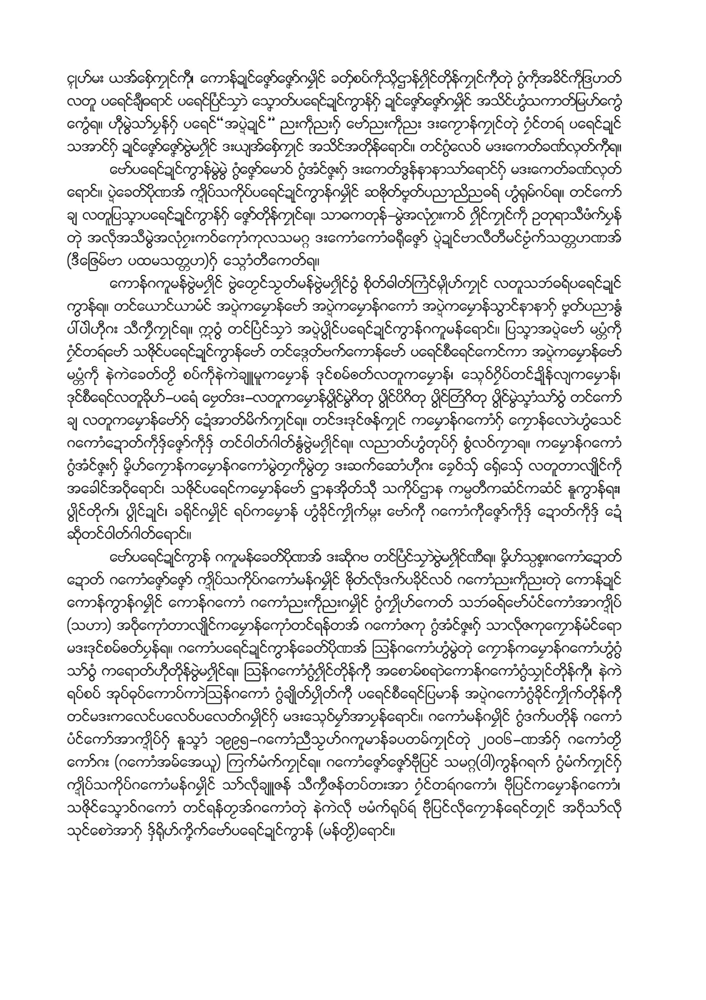

**OCR Result:**

```
္ၚိုဟ်မးယအ်ပဂှ်ၠုၚ်ကီုကာန်ဍပင်ဇၞော်ဇၞော်ဂမၠို်ပါတှ်ပပ်ကဵု္ၚိာန်ဂၠိုင်တိုန်ၠုၚ်ကိုုဲဂွံုခိင်ကဵုပြိဟာ်
ုရေ််ျိပရာ်ရ််ပြံ်သၠာဲသၞာ်ပြရ်ပ်ဍပ်ကွာန်ှ်ဍပ်ဇၞော်ဇၞော်မၠို်္သိ်ဟွံဂာ်မြဟ်ွကွံ
ကွံရ။ဟိုမွဲညာ်ၠန်ှ်ရ်ပ္ၚဲဍင်ညးကုးှ်ာ်းကဵုးးာန်ၠု်တုဲဂၠံ်ရဍင်
သာာ်ှ်ဍုပ်ဇဇၞော်ဇၞော်ွဲပဂၠိုင်ပိးယျ်ဂဂှ်ၠုင်္သိင်တတိုန်ပရ်ာ််ဂွံလ်မပြိးကာ်ပါဏ်လ္ၚာ်ကိုရ
ာ်ရ််ြင်ကွာန်ွွဲဂွံဇၞော်ြမာ်ဂွံံ်ဇၞဂှ်ပိးပက်ွန်နှ်ာနှ်ာ်ြရ်ာ်ှ်မပးာ်ါဏ်္ၚာ်
ရပ်ပ္ၚဲပါတ်ိုဏအ်က္ဍိုပ်ကိုပ်ပရပ်ဍုပ်ကွာန်ဂမၠိုင်ါခိုတ်ၞတ်ပညာညြိညမရ်ဟွံရိမ်ဂပ်ရင်ပြကာ်
ျလုပြသၞာရေပ်ဍုင်ကွာန်ှ်ဇၞော်တိုန်ၠုၚ်ရသာုန်ွဲလုံးက်ဂၠိုင်ကၠုၚ်ကဵုပုရာဳဂြံက်ၠန်
ုဲ္လုသဳမွဲလုံၠးဂ်ကေုာံုလမဂှ်ပဂိးကာံဂာံရိုဇၞော်ပ္ဲဍုပ်ဗလဳတိမ်ပွံက်္တဟအ်
ခိဇြမ်ဗာမ္တဟဂှ်၆သ္ဂာံတာိွကာ်ရ
ကာန်ဂကုမနှ်ပွဲမဂၠိုင်ပွဲမတၟ်သၟတ်မန်ပွဲမဂၠိုပ်ဂွံစိုတ်မါတ်ဂြံပ်မ္ိုဟ်ၠုၚ်တုညာဲမရ်ပရေ်ပ်ဍုင်
ွာန်ရ်ိယာ်ယာမံင်ပၚဲမၠာန်မဗာ်အပၚဲဂမၠာနှ်ဂဂာံပ္ၚဲဂမၠာန်သွာင်နှာှ်ဂှ်ပၞတ်ပာဂွံ
ါပါဟိုဂးသဳကၠိဂၠုပ်ရါ။က္ကွံင်ပြံင်သၠာဲအပ္ၚဲပွိုင်ပရ်ပ်ဍင်ကွာန်ဂကုမန်မရာင်ူပြသၞာအပ္ၚဲမွဳဗာ်မပ္တံကဵု
ဂၠိ်တရမဗာ်သိုင်ပရပ်ဍပ်ကွာန်မဗာ််မပ္ိတ််ာန်မာ်််မ်ာပ္ၚဲမမၠာန်မာ်
မပ္တံကုနှဲကဲါတ်တၟိပ်ကဵုနှ်ဲကဲချူမူဂမၠာနှ်ဒိုင်ဂမ်ဴတ်လတုမၠာန်၊သ္ၚ်ၠိပ််ဍိုန်လျမၠာန်၊
ဒို်ီြရပ်လိုဟ်ံာွွ
ချလုမၠာန်ပဗာ်ှ်ပဍံပ္ာာ်မိက်ၠုင်ရ။င်ပဂိးပိုပ်ဇြန်ၠုင်ကမၠာန်ဂကာံှ်ဂၠာန်လာဲဟွံသင်
(ကာံပြောာ်ကဵုဒှ်ဇၞော်ကဵုဒှ်င်ါတ်ဂါတ်ွံပွဲမဂၠိုင်ရ။လာ်ဟွံတုပ်ှ်ွံ်ၠာရမၠာန်ာံ
ဂွံံပ်ဇၞးဂှ်မၞိဟ်ဂၠောန်ကမၠာန်ဂကာံမွဲတၠကဵွဲၠပဂိးက်ပာံဟိီုဂးမၠေ်ှ်ှ်သှ်ုာျိပ်ကဵု
ပေါင်္တပိုရ်ာင်သိုင်ပရေင်ကမၠာန်ဗာ်ပ္ာစ်အိုတ်သီုသကိုပ်္ာနှ်ကမ္မတိကဍံ်ကဍာံင်ခရိုကွာန်ရရိ
ပွိင်တိုက်ပွိုင်ဍင်၊ခါရိုင်ဂမၠို်ပ်ကမၠာန်ဟွံခိုင်ဂၠိုက်မ္ဂးဗာ်ကီုဂကာံကီုဇၞော်ကဵုှ်ပာာ်ကဵုဒှ်ဍံ
ိဵုတာင်ါတ်ါတ်ရာ်ူ
ဗာ်ရေ်ပ်ဍုပ်ကွာနှ်ဂုမပန်ပ်ပါတိုာ်ပိးိုပြံ်သၠာွဲပဂၠိုင်ဏိရမၞိဟ်္ပၞးဂဂကာံပဍာာ်
ာာ်ဂာံဇၞော်ဇၞော်က္ိုပ်ကိုပ်ဂဂာံမနှ်ဂမၠိုင်ဇိုတ်လဵုဒိက်ပခိုင်လ်ဂကာံြးကဵုြးတုဲဂကာနှ်ဍုင်
ကာန်ကွာန်ဂမၠိုၚ်ကာန်ဂကာံဂကာံြးကဵုညြးဂမၠို်ဂွံၠိုဟ်မကာ်သာဴမရ်မဗာ်ံင်မံဂာံ္ာ္ိုပ်
()ပိဵုကုာံာာျိုင်ကမၠာန်ပဂုာံာင်ရန်တ်ဂာံြိဂုဂွံံပ်ဇၞးဂှ်သာလဵုိဂုၠာန်မံင်ဴရာ
မိးဒို်ဂမ်တ်ၠန်ရာံရ်ပ်ဍင်ကွာန်ပပါတ်ိုဏအ်ပြန်ဂကာံဟွံွဲတုဲၠောန်မမၠာန်ဂဂကာံဟွွံ
သာ်ွံကြရ်ာာ်ဟိုတိုန်ပွဲပဂၠိုၚ်ရပြန်ဂကာံွံဂၠိုၚ်တိုန်ကီုတာမ်ပရာဲကာန်ဂြဂကာံွံၠုၚ်တိုန်ကီုနှ်ဲကဲ
ပ်ပပ်ုပ်မုပ်ွကော်ကာဲ်ြန်ဂကာံဂွံချိုတ်ပၠိုတ်ကီုပရေၚ်ဂဳိမြရေ်ပ်ပြမာနှ်္ပ္ၚဲဂမကာံဂွံခိုင်ကၠိုက်တိုန်ကီု
်မပိဂဂ်ပ်မၠိ်ှ်မးၚေ်မၠာ်ာၠန်ရ်ာံမန်ဂမၠို်ဂွံိိုန်ံ
ပံင်မဂကာ်အာက္ိုပ်ှ်ဒှုဲသၞာံွွဴကာံညဳသၟိဟ်ဂကုမာနှ်ါပာမ်ၠုၚ်တုဲ၂အ်ဂှ်ဂကာံတၟိ
ကာ်ဂး(ဂကာံ္တပ်ပယျဂြက်မံက်ၠုၚ်ရ။ဂ၆ကာံဇၞော်ဇၞော်ီုပြင်သမဂွါကွန်ဂရ်က်ဂွံမံက်ၠုင်ဂှ်
က္ိုပ်သကိုပ်ဂကာံမနှ်ဂမၠိုင်သာ်လဵုချူဂြနှ်သိကၠဳဂြနှ်တပ်တး္ာဂၠံၚ်ရဴာံဲပဵီုပြ်ကမၠောန်ဂဂာံ
သိုင်သၞာ်ဂကာံင်ရန်တၟအ်ဂကာံတုဲနှ်ဲကဲလဵုဗမံက်ရိုပ်ရဴပီုပြင်လဵုမဂၠောန်မရ်ၚ်တၠိုၚ်အပိဵုညာ်လဵု
သုင်မာဲာှ်ဒှ်ရိုဟ်ကၞိက်မဗာ်ပရ်ပ်ဍုပ်ကွာန်မနှ်တၟိမြရ်ာပ်ူ
```

----------------------------------------


In [7]:
if not pdf_dir.exists():
    print("PDF directory not found")
else:
    pdfs = sorted(pdf_dir.glob("*.pdf"))
    print(f"Found {len(pdfs)} PDFs\n")

    for pdf_path in pdfs:
        display(Markdown(f"# {pdf_path.name}"))

        try:
            pages = convert_from_path(str(pdf_path))

            for i, page_img in enumerate(pages, start=1):
                display(Markdown(f"## Page {i}"))

                # OCR
                text = ocr.read_text(page_img)

                # Display page
                display_pil_image(page_img)

                # Display OCR result
                display(Markdown("**OCR Result:**"))
                display(Markdown(f"```\n{text}\n```"))

                print("-" * 40)

        except Exception as e:
            print(f"Failed to process {pdf_path.name}: {e}")
